In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import glob

In [2]:
class ImageDataset(Dataset):
    def __init__(self, root_A, root_B, transform=None):
        self.A_paths = sorted(glob.glob(root_A + "/*.jpg"))
        self.B_paths = sorted(glob.glob(root_B + "/*.jpg"))
        self.transform = transform

    def __getitem__(self, index):
        img_A = Image.open(self.A_paths[index % len(self.A_paths)]).convert("RGB")
        img_B = Image.open(self.B_paths[index % len(self.B_paths)]).convert("RGB")

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        return img_A, img_B

    def __len__(self):
        return max(len(self.A_paths), len(self.B_paths))


In [3]:
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super(ResnetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, kernel_size=3, stride=1, padding=1),
            nn.InstanceNorm2d(dim),
        )

    def forward(self, x):
        return x + self.block(x)  # Residual Connection


class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, n_residual_blocks=6):
        super(Generator, self).__init__()
        model = [
            nn.Conv2d(input_nc, 64, kernel_size=7, stride=1, padding=3),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]

        in_features = 64
        for _ in range(n_residual_blocks):
            model += [ResnetBlock(in_features)]

        model += [
            nn.Conv2d(64, output_nc, kernel_size=7, stride=1, padding=3),
            nn.Tanh(),
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


In [4]:
class Discriminator(nn.Module):
    def __init__(self, input_nc):
        super(Discriminator, self).__init__()
        model = [
            nn.Conv2d(input_nc, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=1),
            nn.Sigmoid(),
        ]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G_A2B = Generator(3, 3).to(device)  # A to B generator
G_B2A = Generator(3, 3).to(device)  # B to A generator
D_A = Discriminator(3).to(device)  # Discriminator for domain A
D_B = Discriminator(3).to(device)  # Discriminator for domain B

optimizer_G = optim.Adam(list(G_A2B.parameters()) + list(G_B2A.parameters()), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()

In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataset = ImageDataset(root_A="D:/TARU/IV th year/Sem 8/GenAI Lab/Ex 12/archive/trainA", root_B="D:/TARU/IV th year/Sem 8/GenAI Lab/Ex 12/archive/trainB", transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
epochs = 2
for epoch in range(epochs):
    for i, (real_A, real_B) in enumerate(dataloader):
        real_A, real_B = real_A.to(device), real_B.to(device)

        # Train Generators
        optimizer_G.zero_grad()

        fake_B = G_A2B(real_A)
        fake_A = G_B2A(real_B)

        loss_GAN_A2B = criterion_GAN(D_B(fake_B), torch.ones_like(D_B(fake_B)))
        loss_GAN_B2A = criterion_GAN(D_A(fake_A), torch.ones_like(D_A(fake_A)))

        rec_A = G_B2A(fake_B)
        rec_B = G_A2B(fake_A)

        loss_cycle_A = criterion_cycle(rec_A, real_A)
        loss_cycle_B = criterion_cycle(rec_B, real_B)

        loss_G = loss_GAN_A2B + loss_GAN_B2A + 10.0 * (loss_cycle_A + loss_cycle_B)
        loss_G.backward()
        optimizer_G.step()

        # Train Discriminators
        optimizer_D_A.zero_grad()
        optimizer_D_B.zero_grad()

        loss_D_A = (criterion_GAN(D_A(real_A), torch.ones_like(D_A(real_A))) +
                    criterion_GAN(D_A(fake_A.detach()), torch.zeros_like(D_A(fake_A)))) * 0.5

        loss_D_B = (criterion_GAN(D_B(real_B), torch.ones_like(D_B(real_B))) +
                    criterion_GAN(D_B(fake_B.detach()), torch.zeros_like(D_B(fake_B)))) * 0.5

        loss_D_A.backward()
        loss_D_B.backward()
        optimizer_D_A.step()
        optimizer_D_B.step()

        print(f"Epoch [{epoch+1}/{epochs}] | Batch [{i+1}/{len(dataloader)}] | "
              f"Loss G: {loss_G.item():.4f} | Loss D_A: {loss_D_A.item():.4f} | Loss D_B: {loss_D_B.item():.4f}")


In [ ]:
os.makedirs("output_images", exist_ok=True)
with torch.no_grad():
    for i, (real_A, real_B) in enumerate(dataloader):
        real_A, real_B = real_A.to(device), real_B.to(device)
        fake_B = G_A2B(real_A)
        fake_A = G_B2A(real_B)
        save_image(fake_B, f"output_images/fake_B_{i}.png")
        save_image(fake_A, f"output_images/fake_A_{i}.png")
        if i == 5: break  # Save only a few images

print("Training completed! Generated images saved in 'output_images'.")

Training completed! Generated images saved in 'output_images'.


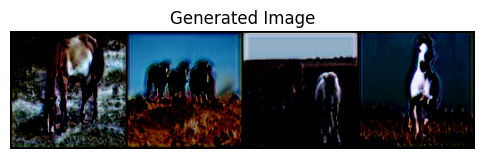

In [ ]:
import matplotlib.pyplot as plt
import PIL.Image as Image

# Load a generated image (update path accordingly)
image_path = "output_images/fake_B_0.png"
generated_image = Image.open(image_path)

# Display in VS Code
plt.figure(figsize=(6, 6))
plt.imshow(generated_image)
plt.axis("off")
plt.title("Generated Image")
plt.show()
